# Module 5 — Day 3: PyTorch and Practical Neural Networks
## PHY 657, Spring 2026

---

### Recap from Day 1

Last time we:
- Showed that a single neuron = logistic regression
- Built a 2-layer network **from scratch** in numpy
- Derived and implemented backpropagation (= chain rule)
- Classified Ising model phases, showing a neural network outperforms a linear classifier because the relevant feature (|M|) is non-linear

Today we will:
1. Introduce **PyTorch** — a framework that handles backpropagation automatically
2. Explore **depth**: what happens when we add more hidden layers?
3. Study **overfitting** in neural networks and how to detect it
4. Apply everything to a more challenging version of the Ising problem

---
## Part 0: Setup

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})
RNG = np.random.default_rng(42)

# set torch seed for reproducibility
torch.manual_seed(42)

# use GPU if available (not required)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


---
## Part 1: Why PyTorch?

Last time we wrote the backward pass by hand. For a 2-layer network with sigmoid activations, that was manageable.

But for a network with 5 layers, different activation functions, dropout, batch normalization, etc., deriving and debugging gradients by hand becomes impractical.

**PyTorch** (and similar frameworks like TensorFlow) solve this with **automatic differentiation**: you define the forward pass, and the framework computes all gradients for you.

### The key ideas in PyTorch

- **Tensors**: like numpy arrays, but they track computation history for automatic gradients
- **`nn.Module`**: base class for defining network architectures
- **`loss.backward()`**: computes all gradients via backpropagation automatically
- **`optimizer.step()`**: updates parameters using the computed gradients

Let's rebuild our Day 2 network in PyTorch and see how much simpler it becomes.

### 1.1 Regenerate the Ising data

We'll reuse the same Ising model data generator from Day 1.

In [2]:
def ising_monte_carlo(L, T, n_steps=5000, rng=None):
    """Metropolis Monte Carlo for 2D Ising model."""
    if rng is None:
        rng = np.random.default_rng()
    spins = rng.choice([-1, 1], size=(L, L))
    for step in range(n_steps):
        i, j = rng.integers(0, L, size=2)
        neighbors = (
            spins[(i+1) % L, j] + spins[(i-1) % L, j] +
            spins[i, (j+1) % L] + spins[i, (j-1) % L]
        )
        dE = 2 * spins[i, j] * neighbors
        if dE <= 0 or rng.random() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins


def generate_ising_dataset(L=10, n_samples_per_phase=500, n_mc_steps=10000, rng=None):
    """Generate labeled Ising configurations: ordered (0) vs disordered (1)."""
    if rng is None:
        rng = np.random.default_rng()
    T_c = 2.269
    T_low = rng.uniform(1.0, 1.8, size=n_samples_per_phase)
    T_high = rng.uniform(2.8, 4.0, size=n_samples_per_phase)
    
    configs, labels, temps = [], [], []
    for T in T_low:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=rng)
        configs.append(spins.flatten()); labels.append(0); temps.append(T)
    for T in T_high:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=rng)
        configs.append(spins.flatten()); labels.append(1); temps.append(T)
    
    X = np.array(configs, dtype=np.float32)
    y = np.array(labels, dtype=np.float32)
    T_arr = np.array(temps)
    idx = rng.permutation(len(y))
    return X[idx], y[idx], T_arr[idx]


print("Generating Ising data...")
X_ising, y_ising, T_ising = generate_ising_dataset(
    L=10, n_samples_per_phase=500, n_mc_steps=8000, rng=RNG
)

X_tr, X_te, y_tr, y_te, T_tr, T_te = train_test_split(
    X_ising, y_ising, T_ising, test_size=0.3, random_state=0, stratify=y_ising
)
print(f"Train: {len(y_tr)}, Test: {len(y_te)}, Features: {X_tr.shape[1]}")

Generating Ising data...
Train: 700, Test: 300, Features: 100


### 1.2 From numpy to PyTorch tensors

The first step is converting our numpy arrays to PyTorch tensors. A `DataLoader` handles batching and shuffling automatically.

In [8]:
# Convert to PyTorch tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
y_te_t = torch.tensor(y_te, dtype=torch.float32).to(device)

# Create DataLoader for mini-batch training
train_dataset = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print(f"Tensor shapes: X_train {X_tr_t.shape}, y_train {y_tr_t.shape}")

Tensor shapes: X_train torch.Size([700, 100]), y_train torch.Size([700])


### 1.3 Define the network

In PyTorch, we define a network as a class that inherits from `nn.Module`. We only need to write the forward pass — PyTorch computes the backward pass automatically.

Compare this to Day 1 where we wrote both `forward()` and `backward()` by hand.

In [9]:
class SimpleNet(nn.Module):
    """A simple feedforward network with one hidden layer."""
    
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        h = torch.sigmoid(self.hidden(x))   # hidden layer + activation
        out = torch.sigmoid(self.output(h))  # output layer + sigmoid
        return out.squeeze(-1)               # shape (N,)


# Create the network
net = SimpleNet(input_dim=100, hidden_dim=20).to(device)
print(net)
print(f"\nTotal parameters: {sum(p.numel() for p in net.parameters())}")

SimpleNet(
  (hidden): Linear(in_features=100, out_features=20, bias=True)
  (output): Linear(in_features=20, out_features=1, bias=True)
)

Total parameters: 2041


### 1.4 The training loop

The PyTorch training loop has a simple rhythm:

```
for each epoch:
    for each batch:
        1. Forward pass  → compute predictions
        2. Compute loss
        3. Backward pass → compute gradients (automatic!)
        4. Update parameters
        5. Zero gradients for next iteration
```

Notice steps 3 and 5 — these are the parts that PyTorch automates. On Day 2, step 3 was our entire `backward()` function.

In [10]:
def train_pytorch(model, train_loader, X_test, y_test, lr=0.01, n_epochs=100, verbose=True):
    """
    Train a PyTorch model and track train/test loss.
    """
    criterion = nn.BCELoss()  # binary cross-entropy — same loss as Day 2
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        for X_batch, y_batch in train_loader:
            # forward
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            # backward (automatic!)
            optimizer.zero_grad()
            loss.backward()
            
            # update
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        train_losses.append(epoch_loss / n_batches)
        
        # evaluate on test set
        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)
            test_loss = criterion(y_pred_test, y_test).item()
            test_losses.append(test_loss)
        
        if verbose and epoch % 20 == 0:
            acc = ((y_pred_test > 0.5).float() == y_test).float().mean().item()
            print(f"  epoch {epoch:4d}  train_loss={train_losses[-1]:.4f}  "
                  f"test_loss={test_loss:.4f}  test_acc={acc:.2%}")
    
    return train_losses, test_losses

In [11]:
print("Training with PyTorch...")
net = SimpleNet(input_dim=100, hidden_dim=20).to(device)
train_losses, test_losses = train_pytorch(
    net, train_loader, X_te_t, y_te_t, lr=0.01, n_epochs=150
)

Training with PyTorch...
  epoch    0  train_loss=0.6961  test_loss=0.6958  test_acc=38.67%
  epoch   20  train_loss=0.1242  test_loss=0.3039  test_acc=87.67%
  epoch   40  train_loss=0.0262  test_loss=0.2926  test_acc=88.67%
  epoch   60  train_loss=0.0113  test_loss=0.3159  test_acc=88.67%
  epoch   80  train_loss=0.0063  test_loss=0.3343  test_acc=89.00%
  epoch  100  train_loss=0.0042  test_loss=0.3535  test_acc=88.00%
  epoch  120  train_loss=0.0030  test_loss=0.3683  test_acc=88.00%
  epoch  140  train_loss=0.0022  test_loss=0.3819  test_acc=88.00%


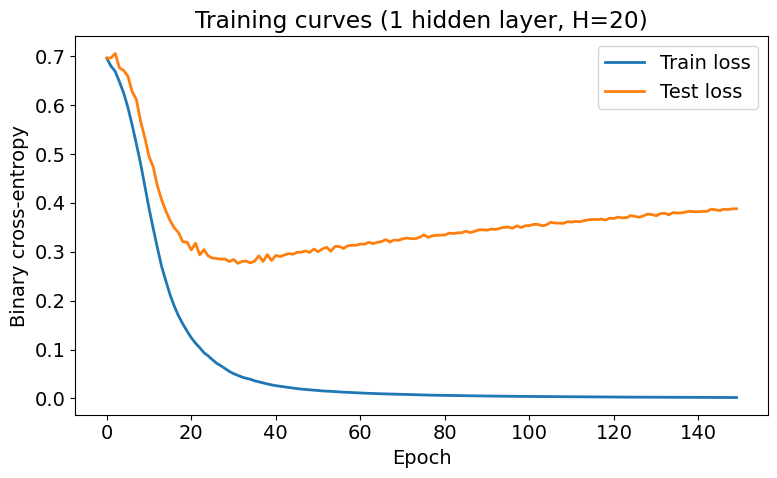

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train loss', lw=2)
ax.plot(test_losses, label='Test loss', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary cross-entropy')
ax.set_title('Training curves (1 hidden layer, H=20)')
ax.legend()
plt.tight_layout()
plt.show()

### 1.5 Comparing to last week

Let's verify the PyTorch network achieves similar (or better) performance to our from-scratch implementation.

Note that PyTorch uses the **Adam** optimizer by default rather than plain gradient descent. Adam adapts the learning rate for each parameter individually — it's like gradient descent with a 'smart' learning rate. This often converges faster and more reliably.

In [13]:
# Evaluate
net.eval()
with torch.no_grad():
    y_prob_nn = net(X_te_t).cpu().numpy()

y_pred_nn = (y_prob_nn > 0.5).astype(int)
acc_nn = accuracy_score(y_te, y_pred_nn)

# Compare with logistic regression
clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_tr, y_tr)
acc_lr = clf_lr.score(X_te, y_te)

print(f"Logistic regression: {acc_lr:.2%}")
print(f"Neural network:      {acc_nn:.2%}")

Logistic regression: 68.00%
Neural network:      88.00%


---
## Part 2: Going Deeper — Multiple Hidden Layers

So far we have used one hidden layer. A key question: **does adding more layers help?**

Deeper networks can represent more complex functions, but they are also harder to train and more prone to overfitting. This is the bias-variance tradeoff again.

### A flexible network builder

Let's write a general network class that accepts any list of hidden layer sizes.

In [14]:
class FlexNet(nn.Module):
    """
    Flexible feedforward network.
    
    hidden_sizes: list of ints, e.g. [32, 16] for 2 hidden layers
    activation: 'sigmoid', 'relu', or 'tanh'
    """
    def __init__(self, input_dim, hidden_sizes, activation='relu'):
        super().__init__()
        
        act_map = {'sigmoid': nn.Sigmoid, 'relu': nn.ReLU, 'tanh': nn.Tanh}
        act_fn = act_map[activation]
        
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())  # output probability
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


# Example: 3-layer network
net_deep = FlexNet(100, [64, 32, 16], activation='relu').to(device)
print(net_deep)
n_params = sum(p.numel() for p in net_deep.parameters())
print(f"\nTotal parameters: {n_params:,}")

FlexNet(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 9,089


### 2.1 Depth comparison

Let's compare networks with different depths on the same Ising data. We use ReLU activations for the hidden layers — this is the modern default and tends to train better than sigmoid for deeper networks.

In [15]:
architectures = {
    'Shallow [20]': [20],
    'Medium [64, 32]': [64, 32],
    'Deep [64, 32, 16]': [64, 32, 16],
    'Very deep [64, 64, 32, 16]': [64, 64, 32, 16],
}

results = {}

for name, hidden in architectures.items():
    print(f"\nTraining: {name}")
    torch.manual_seed(42)
    model = FlexNet(100, hidden, activation='relu').to(device)
    n_p = sum(p.numel() for p in model.parameters())
    
    tr_loss, te_loss = train_pytorch(
        model, train_loader, X_te_t, y_te_t,
        lr=0.001, n_epochs=150, verbose=False
    )
    
    model.eval()
    with torch.no_grad():
        y_prob = model(X_te_t).cpu().numpy()
    acc = accuracy_score(y_te, (y_prob > 0.5).astype(int))
    fpr_m, tpr_m, _ = roc_curve(y_te, y_prob)
    auc_m = auc(fpr_m, tpr_m)
    
    results[name] = {
        'train_loss': tr_loss, 'test_loss': te_loss,
        'acc': acc, 'auc': auc_m, 'fpr': fpr_m, 'tpr': tpr_m,
        'n_params': n_p
    }
    print(f"  params={n_p:,}, acc={acc:.2%}, AUC={auc_m:.4f}")


Training: Shallow [20]
  params=2,041, acc=95.00%, AUC=0.9826

Training: Medium [64, 32]
  params=8,577, acc=96.33%, AUC=0.9889

Training: Deep [64, 32, 16]
  params=9,089, acc=97.00%, AUC=0.9860

Training: Very deep [64, 64, 32, 16]
  params=13,249, acc=96.33%, AUC=0.9912


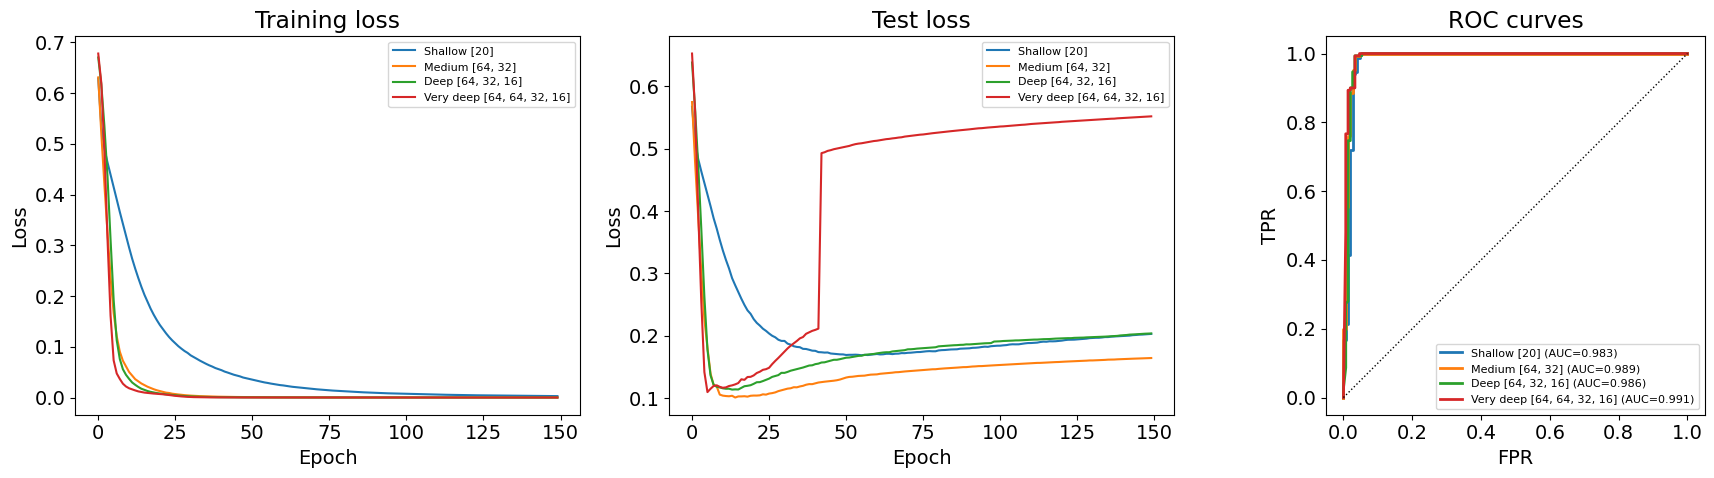

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, r in results.items():
    axes[0].plot(r['train_loss'], lw=1.5, label=name)
    axes[1].plot(r['test_loss'], lw=1.5, label=name)
    axes[2].plot(r['fpr'], r['tpr'], lw=2, label=f"{name} (AUC={r['auc']:.3f})")

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training loss'); axes[0].legend(fontsize=8)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Test loss'); axes[1].legend(fontsize=8)

axes[2].plot([0, 1], [0, 1], 'k:', lw=1)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC curves'); axes[2].legend(fontsize=8)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

### Key observations

- For this problem, a single hidden layer already does well — deeper networks don't dramatically improve performance
- This makes sense: the underlying function (something like |M|) is relatively simple; you don't need many layers to represent it
- Deeper networks have more parameters and may train slower or overfit more easily
- **Rule of thumb for physics applications:** start shallow and only add depth if you have evidence it helps on a validation set

---
## Breakout Exercise (~10 min)

**Pause here and work with your partner.**

I'm going to train a network with 3 hidden layers of [128, 64, 32] neurons — that's over 15,000 parameters — on only **100 training samples** from the Ising dataset.

Before I run it:

1. **Sketch** (on paper) what you expect the training loss curve to look like over 500 epochs.
2. **Sketch** what you expect the test loss curve to look like on the same axes.
3. At what epoch (roughly) do you think the test loss will be lowest?
4. What is the name for what happens after that point?

Think about: how does this relate to fitting a high-order polynomial to a small number of data points (Module 1)?

We'll compare your sketches to the real result.

---
## Part 3: Overfitting in Neural Networks

### The train-test gap

Just like polynomial regression in Module 1 and classification in Module 4, neural networks can **overfit**: they memorize the training data instead of learning the underlying pattern.

The signature of overfitting: **training loss keeps decreasing but test loss starts increasing.**

Let's deliberately create this situation by using a very large network on a small dataset.

In [17]:
# Use only 100 training samples but a large network
X_small = X_tr_t[:100]
y_small = y_tr_t[:100]
small_dataset = TensorDataset(X_small, y_small)
small_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

print("Training large network on small dataset (overfitting demo)...")
torch.manual_seed(42)
net_overfit = FlexNet(100, [128, 64, 32], activation='relu').to(device)
n_params_overfit = sum(p.numel() for p in net_overfit.parameters())
print(f"Parameters: {n_params_overfit:,}, Training samples: 100")

tr_loss_of, te_loss_of = train_pytorch(
    net_overfit, small_loader, X_te_t, y_te_t,
    lr=0.001, n_epochs=500, verbose=False
)

Training large network on small dataset (overfitting demo)...
Parameters: 23,297, Training samples: 100



Best test loss at epoch 17
After that, the network memorizes training data and generalizes worse.


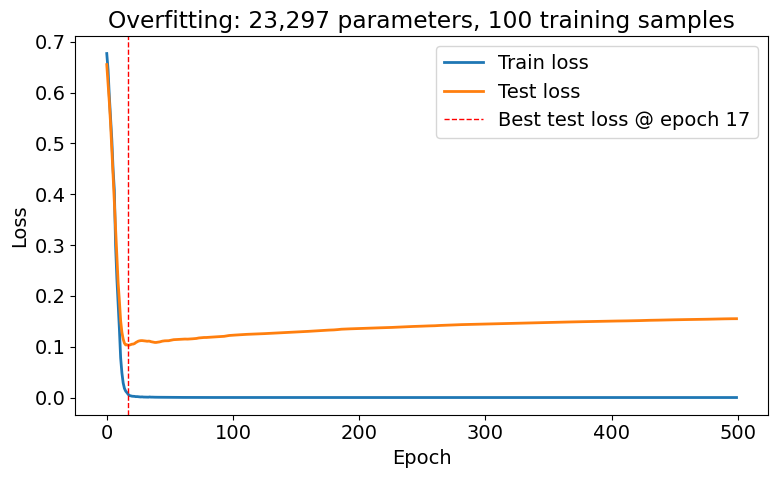

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tr_loss_of, label='Train loss', lw=2)
ax.plot(te_loss_of, label='Test loss', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title(f'Overfitting: {n_params_overfit:,} parameters, 100 training samples')
ax.legend()

# mark where test loss starts increasing
best_epoch = np.argmin(te_loss_of)
ax.axvline(best_epoch, color='red', ls='--', lw=1, label=f'Best test loss @ epoch {best_epoch}')
ax.legend()

plt.tight_layout()
#@plt.yscale('log')

print(f"\nBest test loss at epoch {best_epoch}")
print(f"After that, the network memorizes training data and generalizes worse.")

### Early stopping

The simplest remedy for overfitting: **stop training when the test loss starts increasing.** This is called **early stopping** and is the neural network equivalent of choosing the polynomial order or regularization strength in Module 1.

In practice, you monitor the **validation loss** (a held-out subset of training data) and stop when it hasn't improved for some number of epochs (called "patience").

### Other regularization techniques

- **Dropout:** During training, randomly set a fraction of neuron outputs to zero. This prevents the network from relying on any single neuron and forces it to learn more robust features.
- **Weight decay:** Add a penalty on large weights to the loss function — exactly L2 regularization, the same $\lambda ||\mathbf{w}||^2$ term from Module 1.
- **More data:** Often the best regularizer. In experimental physics, this may mean running the experiment longer or improving your simulation.

The theme is always the same: **model complexity must be matched to the amount of data.**

---
## Part 4: Activation Functions Matter

On Day 1 we used sigmoid everywhere. Let's compare activations on the Ising problem.

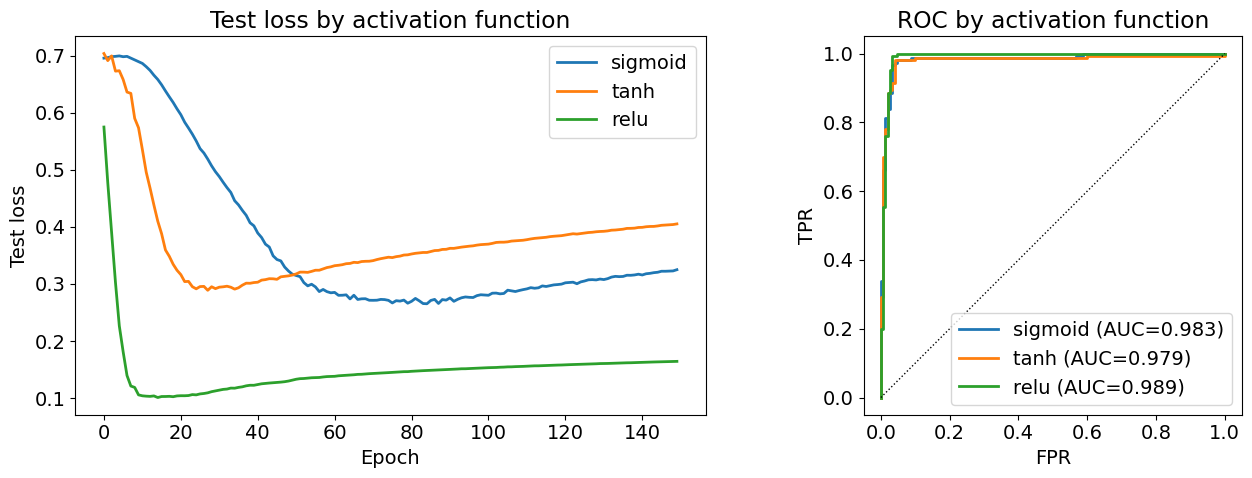

In [23]:
activations = ['sigmoid', 'tanh', 'relu']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for act in activations:
    torch.manual_seed(42)
    model = FlexNet(100, [64, 32], activation=act).to(device)
    tr_l, te_l = train_pytorch(
        model, train_loader, X_te_t, y_te_t,
        lr=0.001, n_epochs=150, verbose=False
    )
    
    model.eval()
    with torch.no_grad():
        y_prob_act = model(X_te_t).cpu().numpy()
    fpr_a, tpr_a, _ = roc_curve(y_te, y_prob_act)
    auc_a = auc(fpr_a, tpr_a)
    
    axes[0].plot(te_l, lw=2, label=f'{act}')
    axes[1].plot(fpr_a, tpr_a, lw=2, label=f'{act} (AUC={auc_a:.3f})')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test loss')
axes[0].set_title('Test loss by activation function'); axes[0].legend()

axes[1].plot([0, 1], [0, 1], 'k:', lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC by activation function'); axes[1].legend()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### Why ReLU is the default

Sigmoid and tanh both suffer from the **vanishing gradient problem**: for large |z|, the derivative is nearly zero, so gradients become tiny and deep layers stop learning.

ReLU ($\max(0, z)$) has a constant gradient of 1 for positive inputs, so gradients flow through deep networks much more effectively. This is why virtually all modern networks use ReLU (or variants like Leaky ReLU) in hidden layers.

Note: we still use sigmoid in the **output** layer for binary classification, because we need a probability between 0 and 1.

---
## Part 5: The Hard Problem — Near the Phase Transition

So far we trained on configurations well below and well above $T_c$. Near the critical point, the physics is ambiguous — configurations are partially ordered with large fluctuations. This is where classification becomes fundamentally difficult.

Let's generate a dataset that includes temperatures near $T_c$ and see how the neural network handles the transition region.

In [24]:
def generate_ising_full_range(L=10, n_per_temp=50, n_mc_steps=10000, rng=None):
    """Generate Ising configs across a range of temperatures."""
    if rng is None:
        rng = np.random.default_rng()
    T_c = 2.269
    temps = np.linspace(1.0, 4.0, 25)
    
    configs, labels, temp_arr = [], [], []
    for T in temps:
        for _ in range(n_per_temp):
            spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=rng)
            configs.append(spins.flatten())
            labels.append(0 if T < T_c else 1)
            temp_arr.append(T)
    
    X = np.array(configs, dtype=np.float32)
    y = np.array(labels, dtype=np.float32)
    T_arr = np.array(temp_arr)
    return X, y, T_arr


print("Generating full-range Ising data (this will take a couple minutes)...")
X_full, y_full, T_full = generate_ising_full_range(
    L=10, n_per_temp=40, n_mc_steps=8000, rng=np.random.default_rng(123)
)
print(f"Total samples: {len(y_full)}")

Generating full-range Ising data (this will take a couple minutes)...
Total samples: 1000


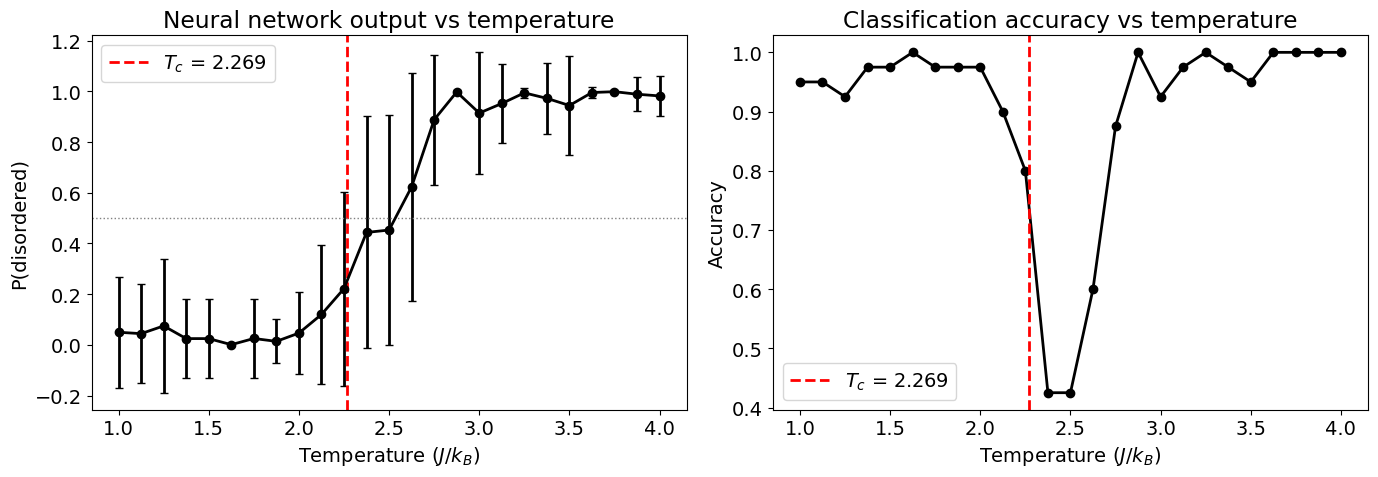

In [25]:
# Train on extreme temperatures, predict across full range
# Use our previously trained network (trained on well-separated phases)

X_full_t = torch.tensor(X_full, dtype=torch.float32).to(device)

# Get best network from depth comparison (use the medium one)
torch.manual_seed(42)
net_best = FlexNet(100, [64, 32], activation='relu').to(device)
train_pytorch(net_best, train_loader, X_te_t, y_te_t, lr=0.001, n_epochs=150, verbose=False)

net_best.eval()
with torch.no_grad():
    y_prob_full = net_best(X_full_t).cpu().numpy()

# Plot P(disordered) vs temperature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Neural network prediction vs T
temps_unique = np.unique(T_full)
mean_prob = [y_prob_full[T_full == T].mean() for T in temps_unique]
std_prob = [y_prob_full[T_full == T].std() for T in temps_unique]

axes[0].errorbar(temps_unique, mean_prob, yerr=std_prob, fmt='ko-', capsize=3, lw=2)
axes[0].axvline(2.269, color='red', ls='--', lw=2, label='$T_c$ = 2.269')
axes[0].axhline(0.5, color='gray', ls=':', lw=1)
axes[0].set_xlabel('Temperature ($J/k_B$)')
axes[0].set_ylabel('P(disordered)')
axes[0].set_title('Neural network output vs temperature')
axes[0].legend()

# Accuracy vs T
acc_vs_T = []
for T in temps_unique:
    mask = T_full == T
    preds = (y_prob_full[mask] > 0.5).astype(int)
    acc_vs_T.append(accuracy_score(y_full[mask], preds))

axes[1].plot(temps_unique, acc_vs_T, 'ko-', lw=2, markersize=6)
axes[1].axvline(2.269, color='red', ls='--', lw=2, label='$T_c$ = 2.269')
axes[1].set_xlabel('Temperature ($J/k_B$)')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Classification accuracy vs temperature')
axes[1].legend()

plt.tight_layout()
plt.show()

### What we see

- Far from $T_c$, the network is highly confident and accurate
- Near $T_c$, the output probability smoothly transitions through 0.5 — the network is uncertain
- Accuracy drops near $T_c$ because the classification problem is **physically ambiguous** there: the system fluctuates between ordered and disordered

This is the **irreducible error** concept from Module 4. No classifier — no matter how powerful — can reliably distinguish phases right at the critical point, because the physics itself is ambiguous.

The beautiful thing: the network's output as a function of temperature traces out something very close to the **order parameter curve**. It has learned the phase transition from raw data, with no knowledge of statistical mechanics.

---
## Part 6: Connections and Perspective

### What a neural network really does

Think of the hidden layers as **learned feature extraction**. The last hidden layer produces a transformed representation of the data, and the output layer performs logistic regression on that representation.

In our Ising example:
- A linear classifier works on the raw spins — and fails because the relevant feature (|M|) is non-linear
- The neural network *learns* to compute non-linear features (something like |M|) in its hidden layers, and then the output layer classifies based on those features

This is the same insight as Module 3: the optimal filter works because it transforms the data into a representation where the signal is easy to extract. A neural network does this automatically.

### When to use neural networks

| Situation | Recommendation |
|---|---|
| Features are well-chosen and boundary is roughly linear | Logistic regression — simpler, faster, interpretable |
| Features are good but boundary is curved | Try a small NN, or KNN, or BDT |
| Raw/high-dimensional data, unknown features | Neural network can learn features automatically |
| Very little training data | Avoid deep networks — use domain knowledge + simple model |
| Need interpretability | Prefer simpler models; inspect NN with care |

### Preview: architectures beyond feedforward

The feedforward networks we built today process each input independently. But some data has additional structure:
- **Images** (or 2D grids like our Ising configurations): **Convolutional Neural Networks** (CNNs) exploit spatial structure
- **Graphs** (e.g., particle interaction networks): **Graph Neural Networks** (GNNs) operate on graph-structured data
- **Sequences** (e.g., time series): **Recurrent Neural Networks** (RNNs) process data step by step

You will hear about CNNs and GNNs in upcoming presentations.

---
## Summary

| Day 1-1 (numpy) | Day 3 (PyTorch) |
|---|---|
| Wrote forward and backward by hand | PyTorch computes gradients automatically |
| Plain gradient descent | Adam optimizer (adaptive learning rate) |
| One hidden layer | Flexible depth |
| Sigmoid only | ReLU, tanh, sigmoid compared |
| Fixed-size dataset | Mini-batch training with DataLoader |

### The recurring themes

- **Loss = negative log-likelihood** (Module 1, 3, 4, and now 5)
- **Gradient descent for optimization** (Module 3 and now 5)
- **Bias-variance tradeoff** (Module 1 polynomial order → Module 4 KNN k → Module 5 network size)
- **Train/test split to detect overfitting** (Module 4 and now 5)
- **The right features matter more than the right algorithm** (Module 3 optimal filter, Module 4 feature engineering exercise, Module 5 |M| vs raw spins)

---
## Remaining class time: work on HW 5

Use the remaining time to continue the homework with your partner. If you finished Problems 1–2 last time, move on to Problem 3 (PyTorch on the Ising model) — the code from today's lecture gives you a starting point. Problem 4 (regression) connects back to Module 1's curve fitting.

